<a href="https://colab.research.google.com/github/ruhaan-reza/Maincraft-Internship/blob/main/student_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



**Load Dataset**

In [2]:
url = "https://raw.githubusercontent.com/ruhaan-reza/Maincraft-Internship/main/student-mat.csv"

df = pd.read_csv(url, sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Checking null values**

In [3]:
df.isnull()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
391,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
392,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Checking Duplicates**

In [4]:
print("number of duplicate rows:", df.duplicated().sum())

number of duplicate rows: 0


**Checking dataset info**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

**Average final grade(G3)**

In [6]:
avg_g3 = df["G3"].mean()
print(f"Average Final Grade (G3): {avg_g3:.2f}")


Average Final Grade (G3): 10.42


**How many students scored above 15 ?**

In [7]:
students_above_15 = (df["G3"] > 15).sum()
print(f"Number of students who scored above 15: {students_above_15}")

Number of students who scored above 15: 40


**Is study time correlated with performance?**

In [8]:
correlation = df["studytime"].corr(df["G3"])
print(f"Correlation between study time and performance: {correlation:.2f}")
if correlation > 0:
    print("There is a positive correlation between study time and performance.")
else:
  print("Weak or negative correlation")



Correlation between study time and performance: 0.10
There is a positive correlation between study time and performance.


**Which gender performs better on average?**





In [9]:
gender_performance = df.groupby("sex")["G3"].mean()
better_perf = gender_performance.idxmax()
print(f"The gender that performs better on average is: {better_perf}")


The gender that performs better on average is: M


**Histogram of grades**

In [10]:
print(df[['G1','G2','G3']].corr())

          G1        G2        G3
G1  1.000000  0.852118  0.801468
G2  0.852118  1.000000  0.904868
G3  0.801468  0.904868  1.000000


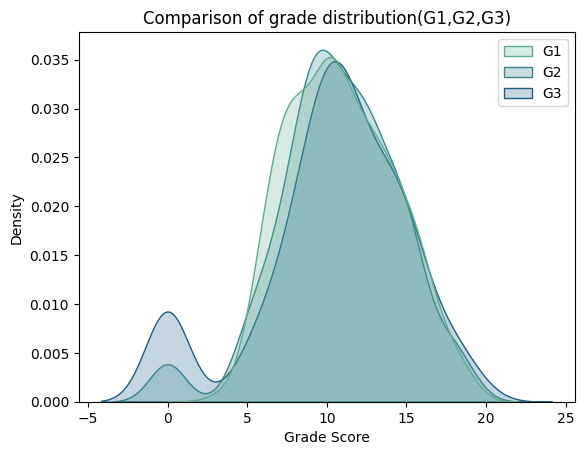

In [11]:
sns.kdeplot(data=df[['G1','G2','G3']], fill=True,palette='crest')
plt.title('Comparison of grade distribution(G1,G2,G3)')
plt.xlabel('Grade Score')
plt.ylabel('Density')
plt.show()

Text(0, 0.5, 'Count of Students')

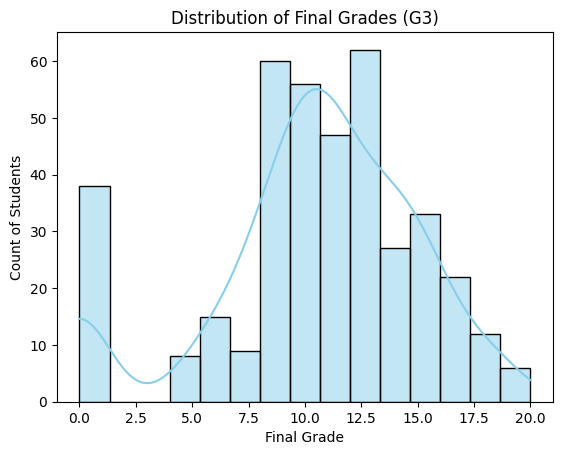

In [12]:
sns.histplot(df['G3'], bins=15,kde=True,color='skyblue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Count of Students')


**Scatterplot: study time vs grades**

<Axes: xlabel='studytime', ylabel='G3'>

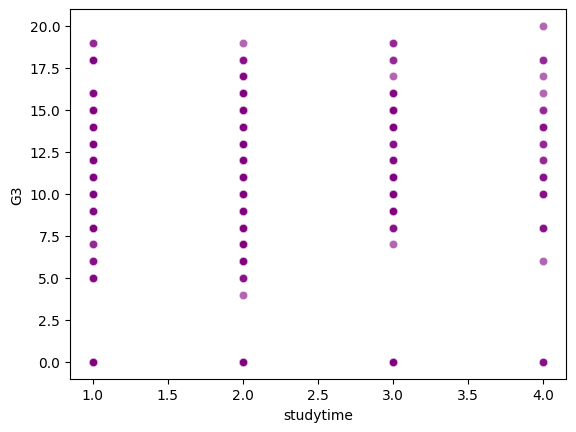

In [13]:
sns.scatterplot(data=df,x='studytime',y='G3',alpha=0.6,color='purple')

<Axes: xlabel='studytime', ylabel='G3'>

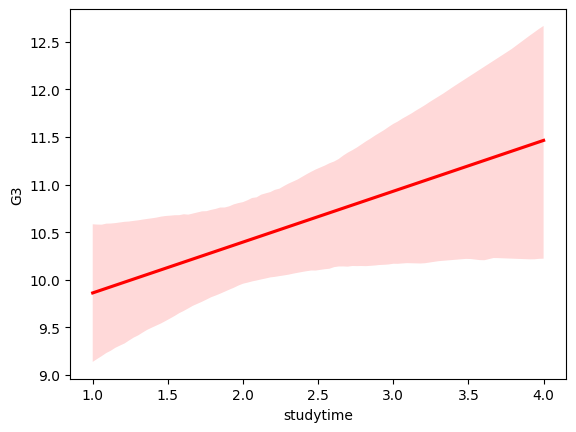

In [15]:
sns.regplot(data=df,x='studytime',y='G3',scatter=False,color='red')


**Bar chart: male vs female average score**

/tmp/ipykernel_8665/2508066388.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='sex',y='G3',errorbar=None,palette='pastel')


Text(0, 0.5, 'Average Score')

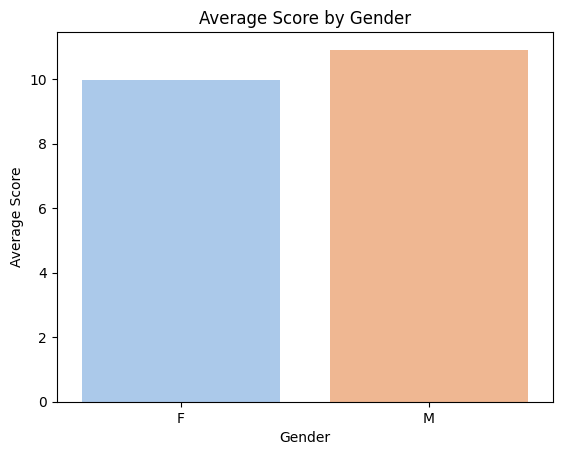

In [17]:
sns.barplot(data=df,x='sex',y='G3',errorbar=None,palette='pastel')
plt.title('Average Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')